# Single-Subject Model Evaluation

Subject-keyed views of the LORO cached predictions.

1. **Per-subject performance** — LORO fold mean per model, ranked by an anchor model.
2. **Subject specificity** — does the prediction match *its* subject's truth more than other subjects' truths at the same region?
3. **Spatial specificity** — does the prediction match its *region*'s truth more than the subject's other regions' truths?

In [172]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [173]:
import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eval_population as eval_population
import src.eval_utils.eval_single_subject as eval_single_subject
importlib.reload(eval_style)
importlib.reload(eval_population)
importlib.reload(eval_single_subject)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *
from src.eval_utils.eval_single_subject import *


## Notebook Configuration

Global / cross-section knobs in the next cell. Per-section knobs (LORO coverage, anchor model, percentile shading, illustrative subjects, specificity) live in mini-config cells immediately above their use sites — edit those in place for fluid in-notebook iteration.


In [174]:
# === Global config ===
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    plam_cache_dirname='plam',
)
print('analysis scope:', CFG.gene_scope)

# Shared across the entire notebook ↓
MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = False

EVAL_GENE_LIST_PATH          = None  # path | None for all genes
VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse


analysis scope: allgenes


## Shared Reconstruction

`PREPOST` + canonical wide tables + filtered view used by Sections 2 & 3.


In [175]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])

subjects: 318
genes: 13618
parcels: 150


In [176]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2820, 13636), 'dlam': (2820, 13636), 'plam': (2820, 13636)}


In [177]:
subject_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
    **VIEW_SUBSET,
)

## Section 1 — Per-Subject Performance

Per-subject LORO mean per model. Subjects are sorted by the **anchor** model's mean; every other model is plotted on the same x positions for direct read-off.

Set `SPARSIFY=N` to keep one subject at every `100/N`-th percentile of the anchor model. The selected subjects come back as `band_subjects` for downstream illustrative-subject work.


In [178]:
# Section 1 config — per-subject performance & illustrative scatters
FOLD_COMBO_COVERAGE_MIN      = 5
FOLD_COMBO_COVERAGE_MAX      = 12
PERFORMANCE_FOLD_METRIC      = 'pearson_r'   # column in fold_perf_df

ANCHOR_MODEL                 = 'plam'        # ranked / shaded / illustrated against this model
SPARSIFY                     = 100           # one subject per (100/SPARSIFY)% of anchor distribution; None = all
BOTTOM_QUANTILE              = 0.20          # static fallback red-shade leftmost % (None = off)
DYNAMIC_BOTTOM_QUANTILE      = True          # override BOTTOM_QUANTILE with anchor>naive crossover
TOP_QUANTILE                 = None          # green-shade rightmost % (None = off)


In [179]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG,
    PREPOST,
    coverage_min=FOLD_COMBO_COVERAGE_MIN,
    coverage_max=FOLD_COMBO_COVERAGE_MAX,
    models=MODELS,
    eval_gene_path=EVAL_GENE_LIST_PATH,
    n_jobs=N_JOBS,
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)

fold_perf_df: (8460, 16)
combo_df: (4494, 17)


In [180]:
subject_perf = compute_subject_performance(
    fold_perf_df,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
)
print('subject_perf:', subject_perf.shape)
display(
    subject_perf.groupby('model', as_index=False)
    .agg(n_subjects=('subject', 'nunique'),
         mean=('mean', 'mean'),
         median=('mean', 'median'),
         worst=('mean', 'min'),
         best=('mean', 'max'))
)

subject_perf: (939, 6)


,model,n_subjects,mean,median,worst,best
0,dlam,313,0.872392,0.895252,0.511890,0.971234
1,naive,313,0.853642,0.851497,0.781220,0.898533
2,plam,313,0.870358,0.880108,0.575761,0.950043


In [181]:
# Percentile-band subject selection anchored on the chosen model.
band_subjects = select_subjects_by_percentile(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    model=ANCHOR_MODEL,
    n_bands=int(SPARSIFY) if SPARSIFY else 100,
)
display(band_subjects)

,selection_index,percentile_anchor,subject,model,mean,std,n_folds,percentile_rank,target_value
0,0,0.5,GTEX-14E7W,plam,0.590118,0.055946,9,0.958466,0.587378
1,1,1.5,GTEX-12WSF,plam,0.595477,0.035529,10,1.916933,0.595026
2,2,2.5,GTEX-1IDJH,plam,0.604914,0.069223,11,2.875399,0.604738
3,3,3.5,GTEX-T2IS,plam,0.609347,0.023535,7,3.833866,0.609335
4,4,4.5,GTEX-183WM,plam,0.637515,0.036172,7,4.792332,0.637527
...,...,...,...,...,...,...,...,...,...
95,95,95.5,GTEX-13112,plam,0.937551,0.022909,10,95.527157,0.937536
96,96,96.5,GTEX-13VXU,plam,0.938021,0.015983,11,96.485623,0.938025
97,97,97.5,GTEX-147F4,plam,0.938538,0.019702,6,97.444089,0.938560
98,98,98.5,GTEX-13PVQ,plam,0.938944,0.022100,11,98.402556,0.939050


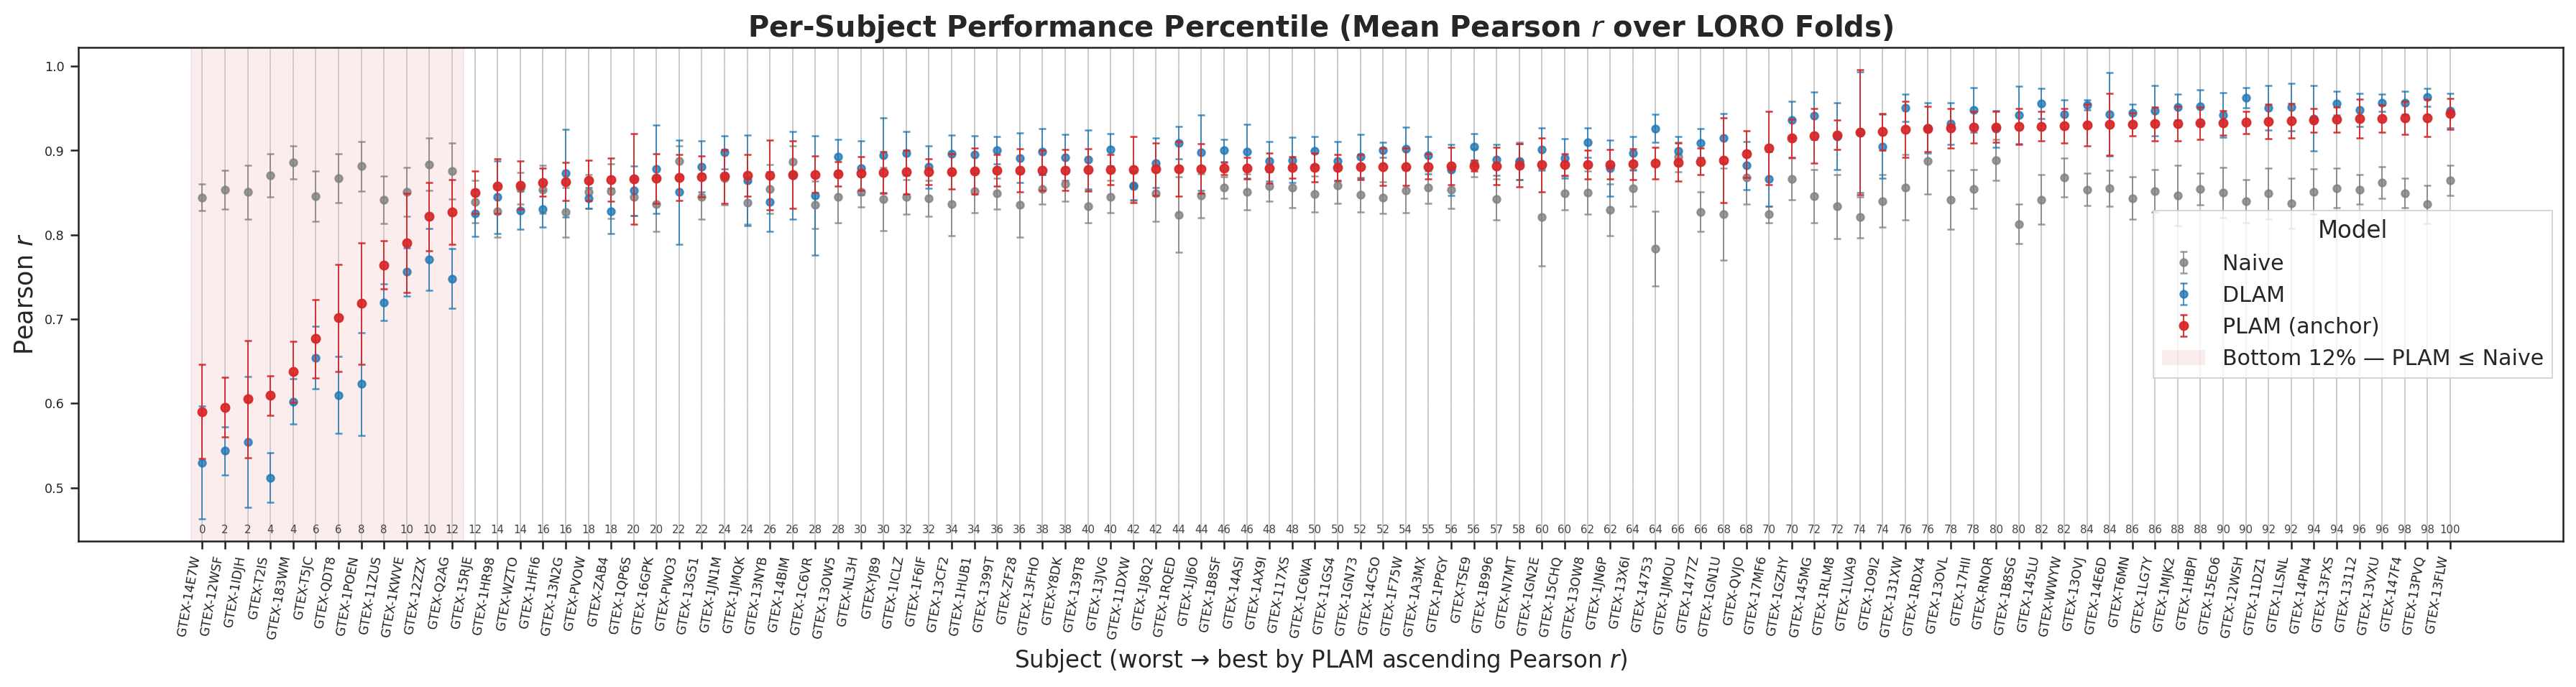

In [182]:
fig, ax, ranked_summary = plot_subject_performance_ranked(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
    sparsify=SPARSIFY,
    anchor_model=ANCHOR_MODEL,
    bottom_quantile=BOTTOM_QUANTILE,
    dynamic_bottom_quantile=DYNAMIC_BOTTOM_QUANTILE,
    top_quantile=TOP_QUANTILE,
)

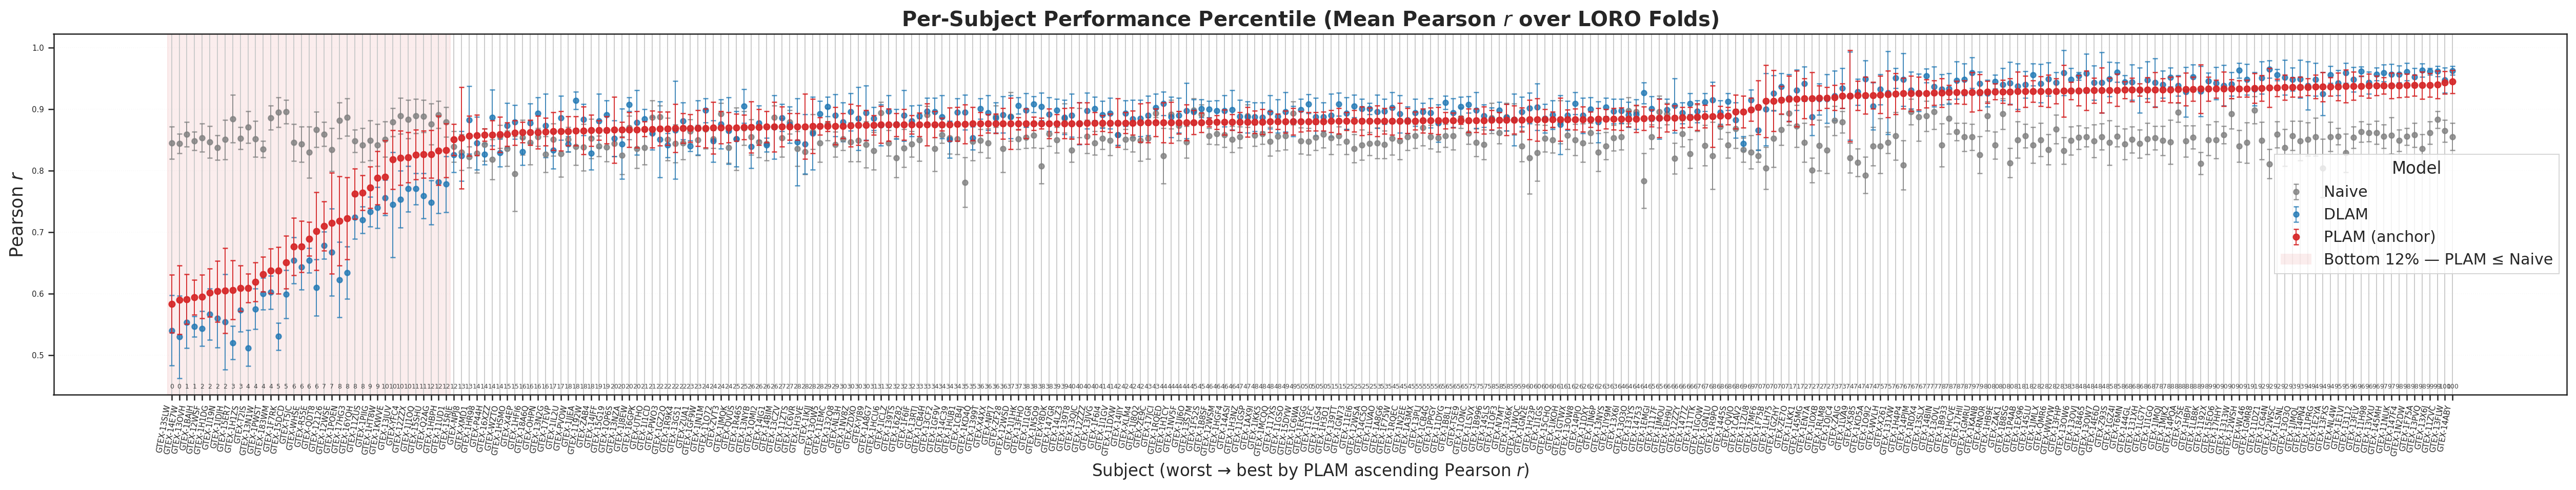

In [183]:
fig, ax, ranked_summary = plot_subject_performance_ranked(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
    sparsify=300,
    anchor_model=ANCHOR_MODEL,
)

### Illustrative subjects (10 / 50 / 90 percentile)

Truth-vs-prediction scatter for one subject at each performance percentile of the anchor model. Color = GTEx tissue.


In [191]:
# Illustrative-subject scatter config
ILLUSTRATIVE_PERCENTILES     = [5, 50, 95]
ILLUSTRATIVE_COLOR_BY        = 'region'      # region | region_group | sex | age | gene
ILLUSTRATIVE_FIGSIZE         = (7.0, 6.0)


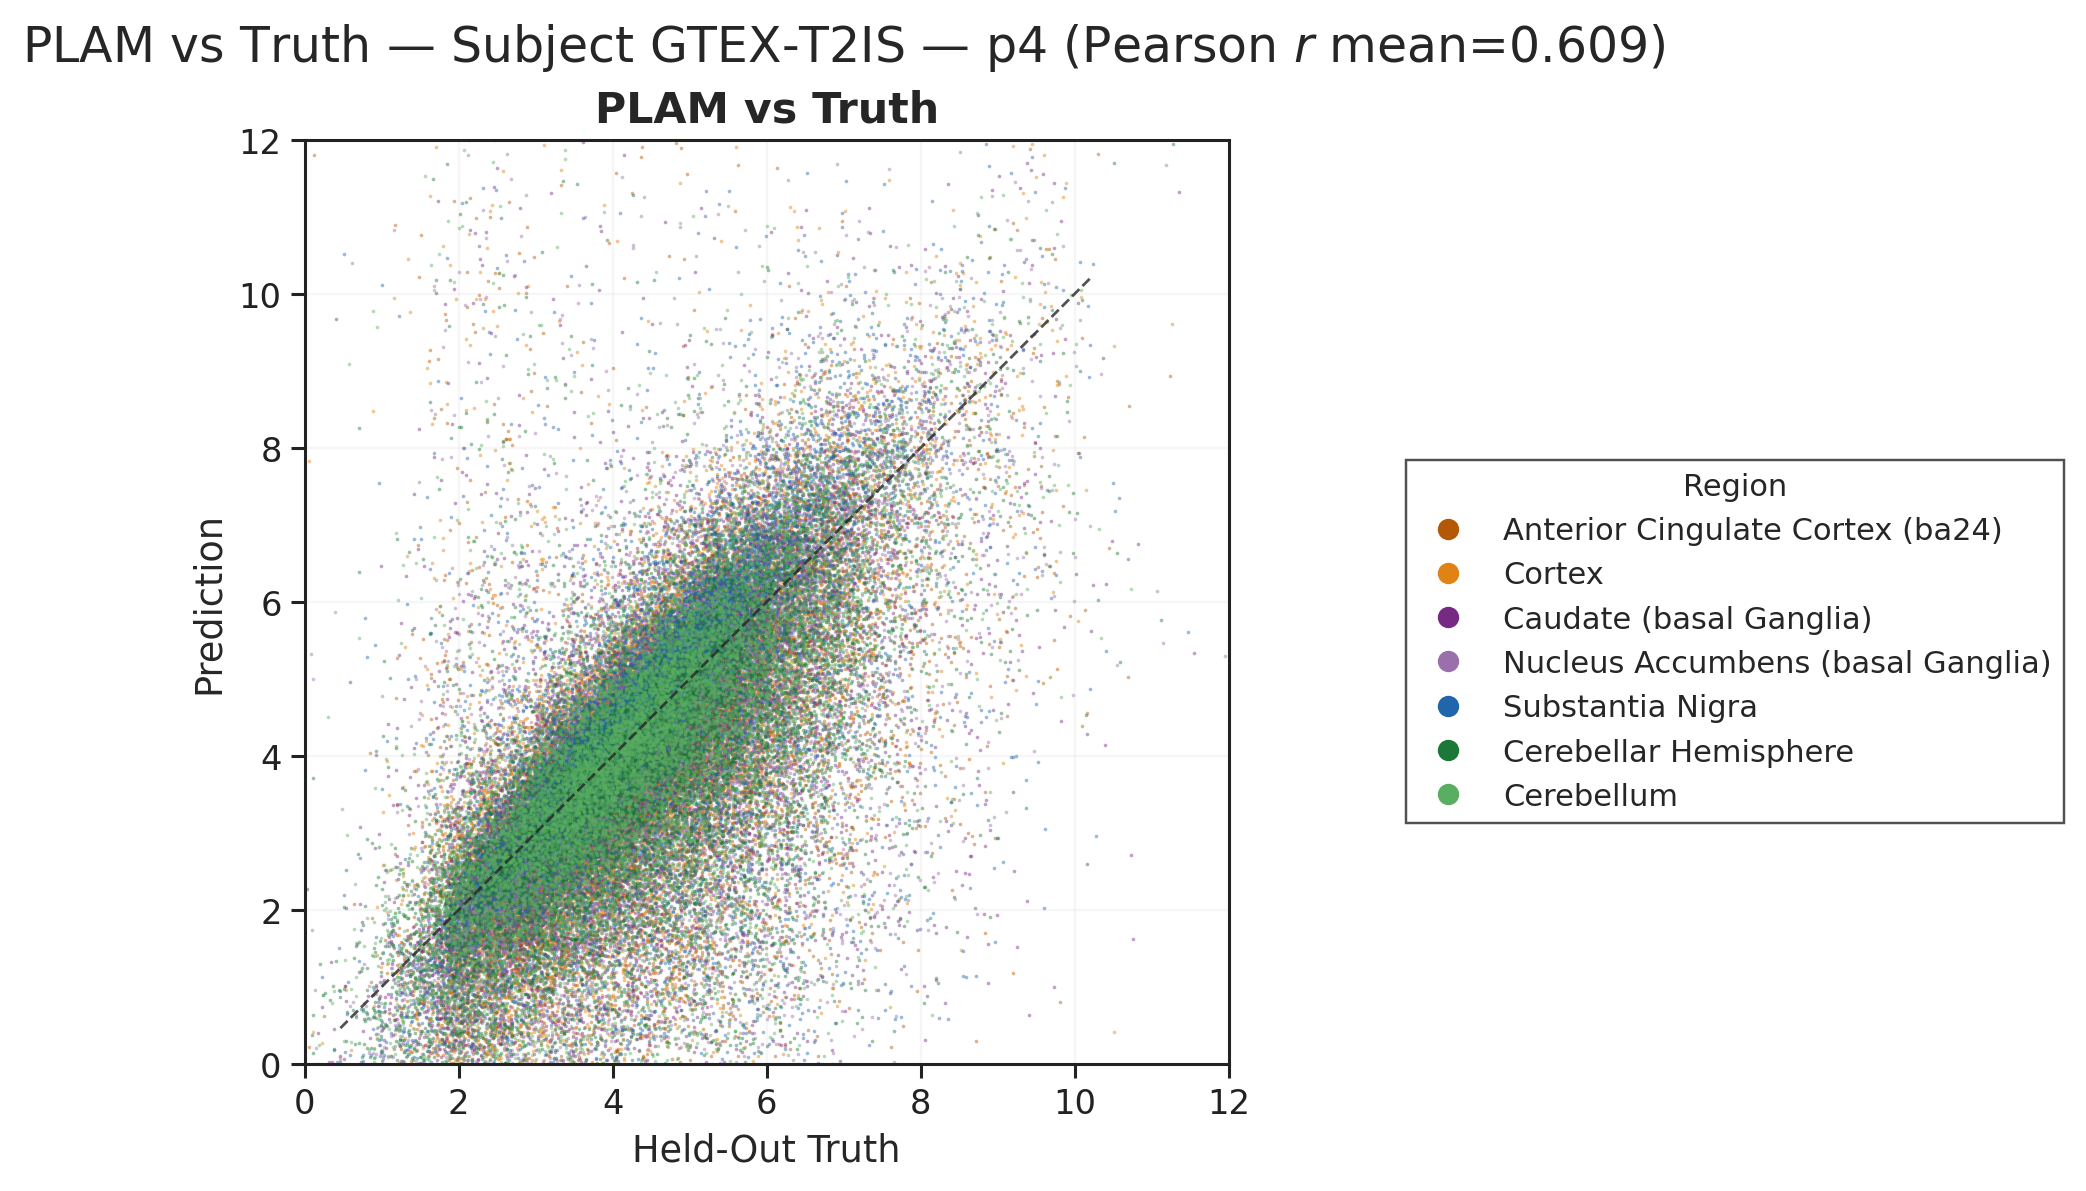

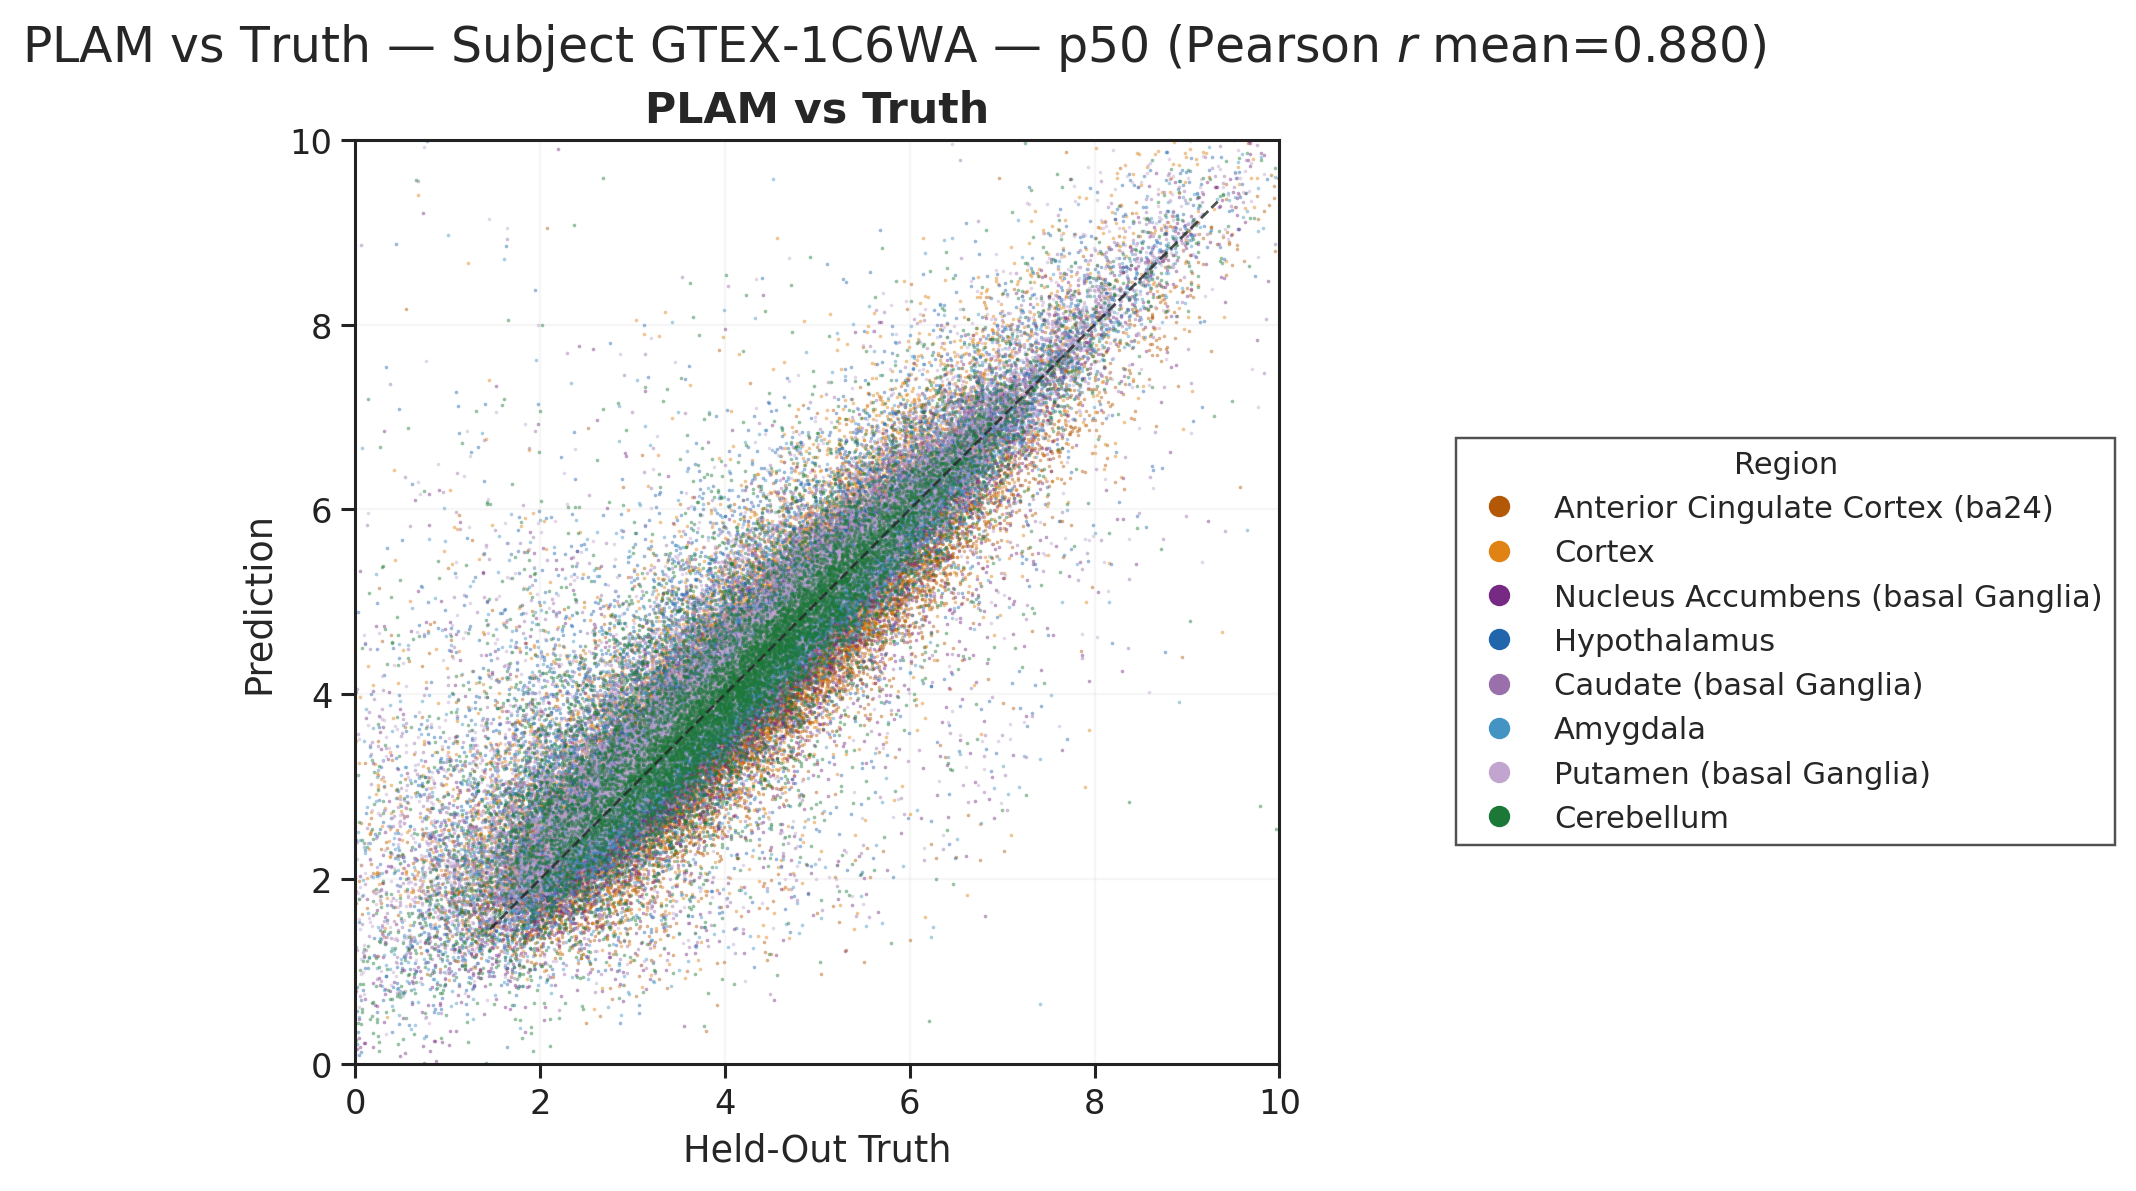

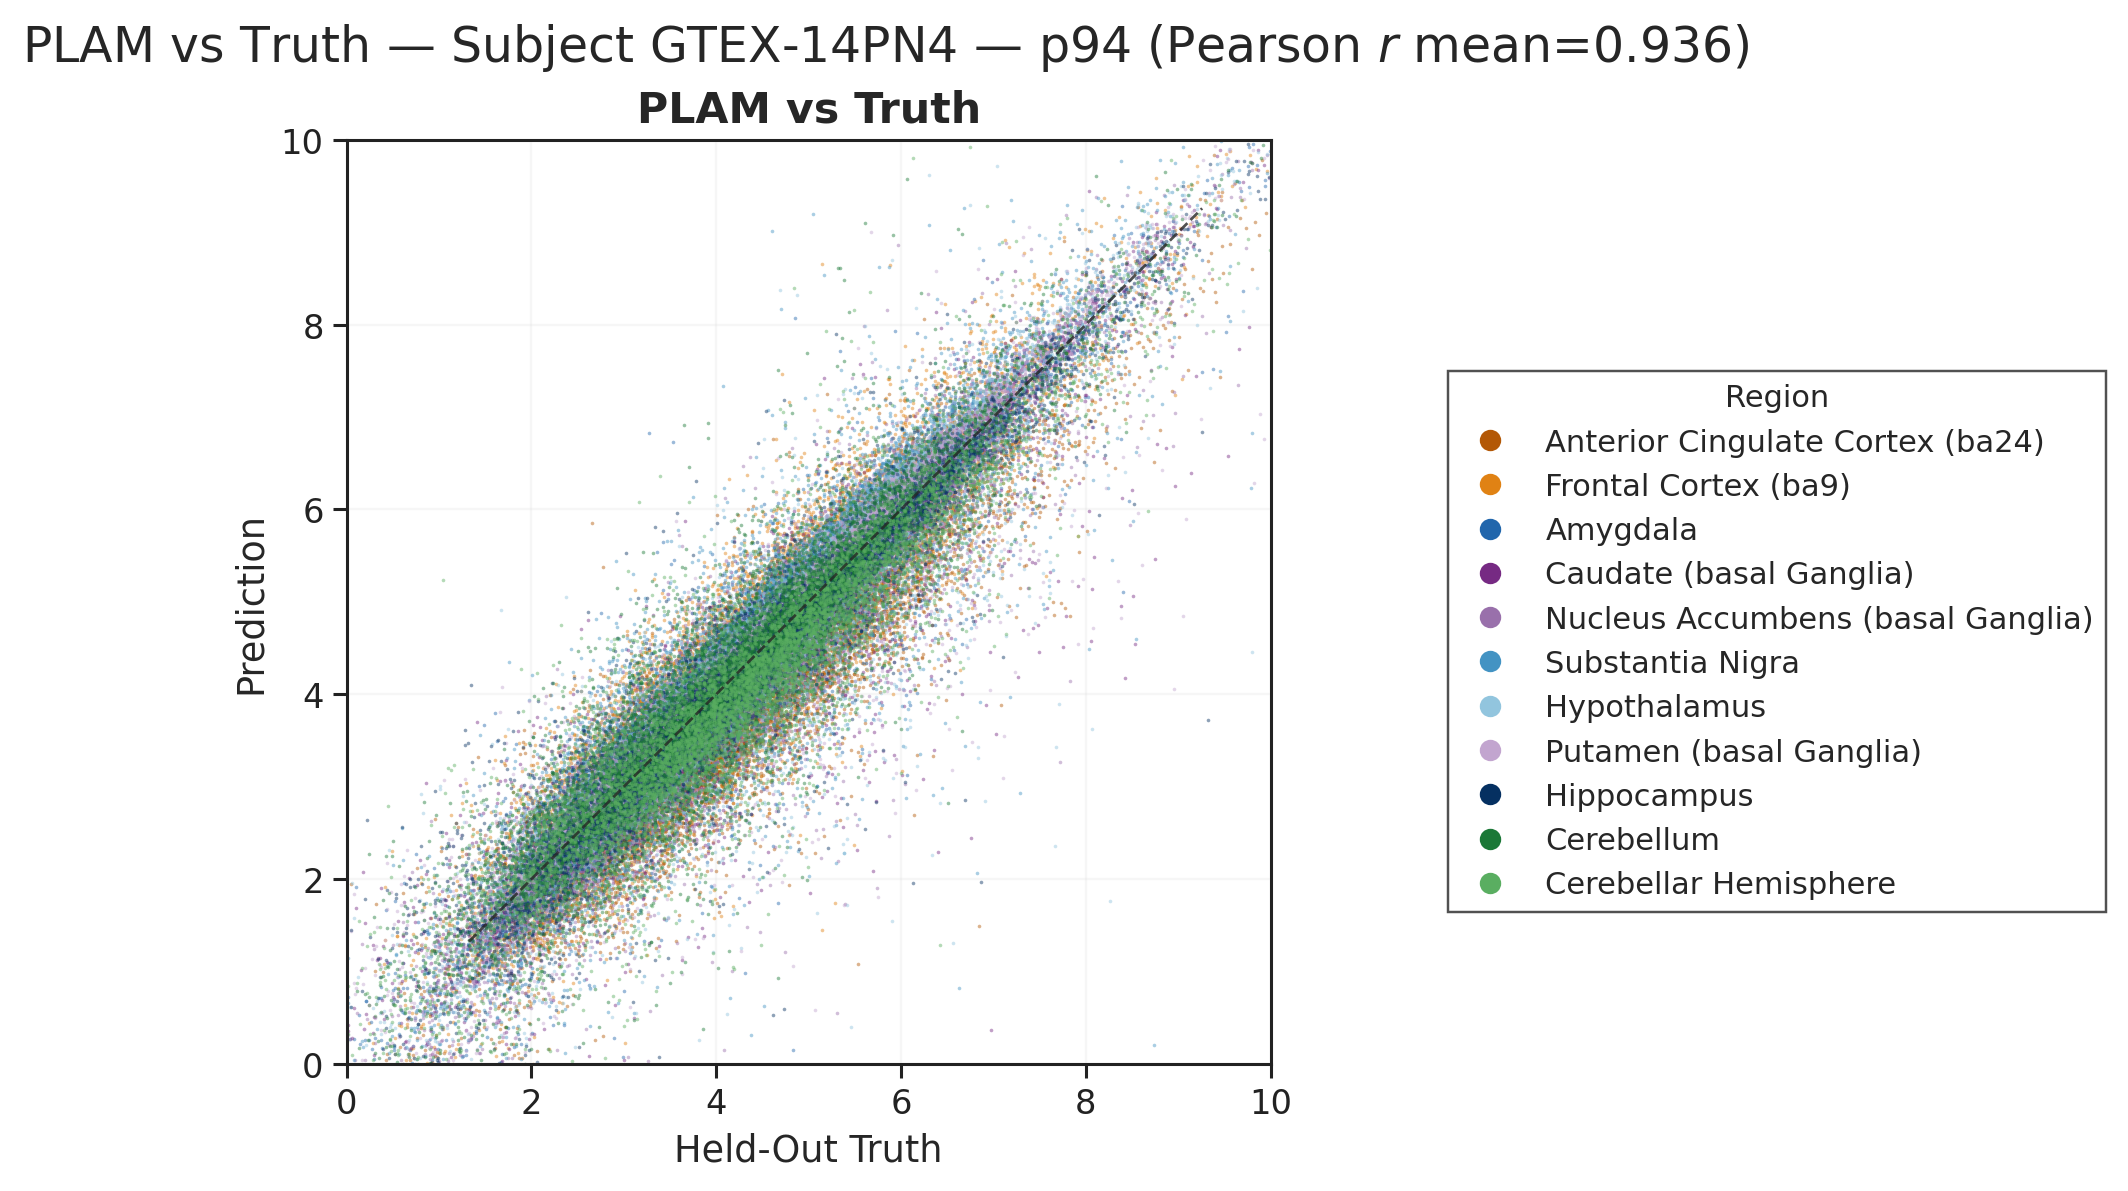

In [192]:
# Pick subjects nearest to ILLUSTRATIVE_PERCENTILES from band_subjects (or compute on-the-fly)
if 'band_subjects' in globals() and not band_subjects.empty:
    pct = band_subjects['percentile_anchor'].astype(float).round().astype(int)
    pct_picks = band_subjects.iloc[[(pct - p).abs().idxmin() for p in ILLUSTRATIVE_PERCENTILES]]
else:
    pct_picks = select_subjects_by_percentile(
        subject_perf, metric=PERFORMANCE_FOLD_METRIC, model=ANCHOR_MODEL,
        percentiles=[p / 100.0 for p in ILLUSTRATIVE_PERCENTILES],
    )

# 3 scatters total — anchor model only, one figure per illustrative-percentile subject.
for _, row in pct_picks.iterrows():
    sub_view = make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=EVAL_GENE_LIST_PATH,
        models=[ANCHOR_MODEL],            # single-model panel
        subjects=[row['subject']],         # single subject
        **{k: v for k, v in VIEW_SUBSET.items() if k != 'subjects'},
    )
    fig, axes = plot_global_prediction_scatter(
        sub_view,
        color_by=ILLUSTRATIVE_COLOR_BY,
        figsize=ILLUSTRATIVE_FIGSIZE,
    )
    fig.suptitle(
        f"{model_label(ANCHOR_MODEL)} vs Truth — Subject {row['subject']} — "
        f"p{float(row['percentile_anchor']):.0f} "
        f"({format_legend_label(PERFORMANCE_FOLD_METRIC)} mean={float(row['mean']):.3f})",
        fontsize=font_size('xxl'), y=0.97,
    )


## Section 2 — Subject Specificity

Per LORO sample, two comparisons of the same prediction:

- **Self** — the subject's own truth at that region.
- **Other Subjects (mean)** — the mean of every other subject's truth at that same region.

Self ≫ Other ⇒ predictions are subject-specific. Self ≈ Other ⇒ predictions are converging on a regional template.


In [186]:
# Sections 2 & 3 — specificity config
SPECIFICITY_REGION_COL       = 'parcel_idx'
SHOW_SPATIAL_SPECIFICITY     = True


,model,n,median_self,median_other,median_delta
0,dlam,2820,0.900927,0.875566,0.026745
1,naive,2820,0.857569,0.862955,-0.000146
2,plam,2820,0.886568,0.870552,0.019468


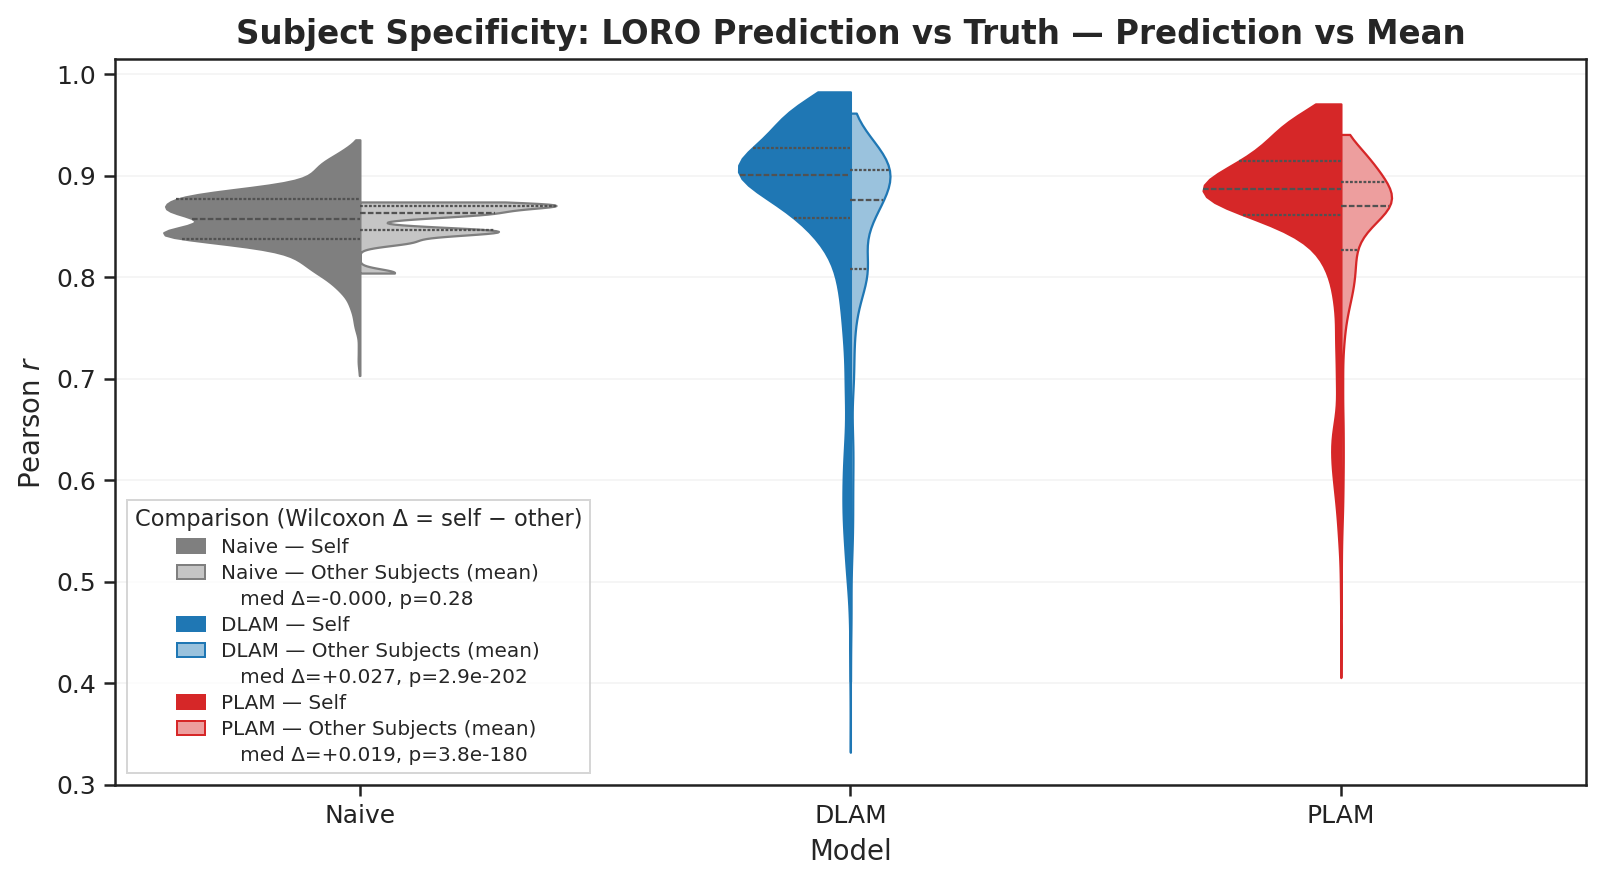

In [187]:
subject_specificity = compute_subject_specificity(
    subject_view,
    region_col=SPECIFICITY_REGION_COL,
    metric=DEFAULT_METRIC,
)

display(
    subject_specificity
    .groupby('model', as_index=False)
    .agg(
        n=('sim_self', 'size'),
        median_self=('sim_self', 'median'),
        median_other=('sim_other_mean', 'median'),
        median_delta=('delta', 'median'),
    )
)

fig, ax = plot_subject_specificity(subject_specificity)

## Section 3 — Spatial Specificity

Per LORO sample, two comparisons of the same prediction:

- **Self** — that *region*'s truth in the same subject.
- **Other Samples (within subject)** — mean of `k − 1` per-region metrics comparing the prediction to each *other* region's truth in the **same** subject.

Self ≫ Other ⇒ predictions are spatially differentiated within a brain. Self ≈ Other ⇒ a single subject-mean profile is being copied to every region (passes Section 2, fails here).


,model,n,median_self,median_other_region,median_delta
0,dlam,2820,0.900927,0.889902,0.013366
1,naive,2820,0.857569,0.823077,0.037267
2,plam,2820,0.886568,0.873660,0.017239


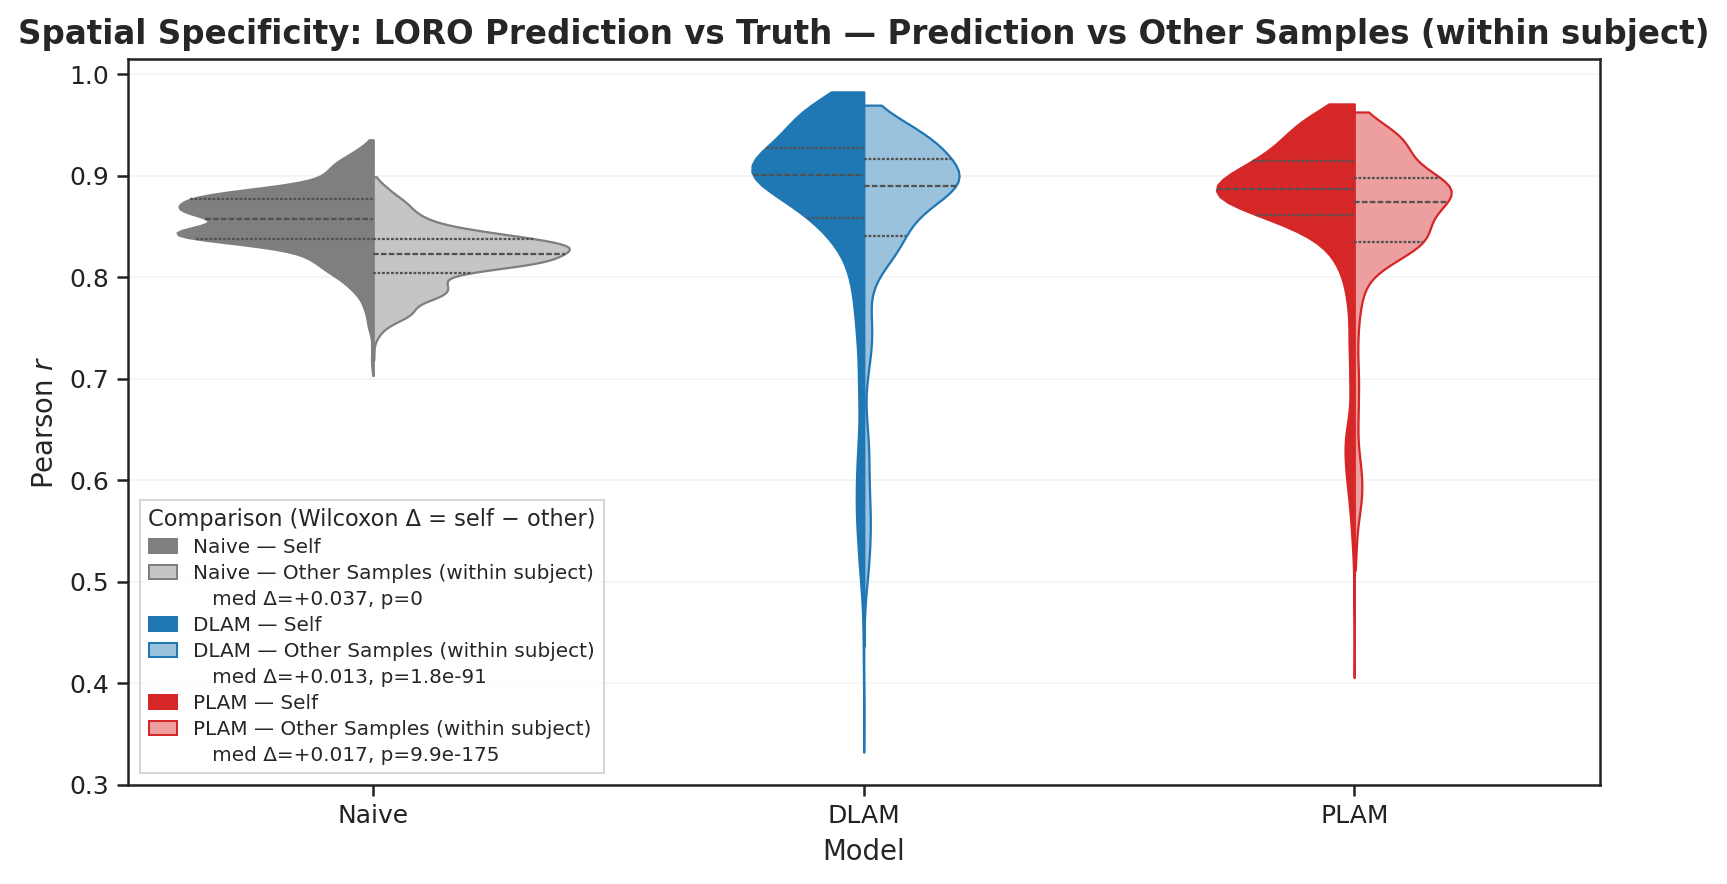

In [188]:
if SHOW_SPATIAL_SPECIFICITY:
    spatial_specificity = compute_spatial_specificity(
        subject_view,
        metric=DEFAULT_METRIC,
        region_col=SPECIFICITY_REGION_COL,
    )
    display(
        spatial_specificity
        .groupby('model', as_index=False)
        .agg(
            n=('sim_self', 'size'),
            median_self=('sim_self', 'median'),
            median_other_region=('sim_other_region_mean', 'median'),
            median_delta=('delta', 'median'),
        )
    )
    fig, ax = plot_spatial_specificity(spatial_specificity)